<a href="https://colab.research.google.com/github/auliatauhid/Data-Science-2026/blob/main/Pertemuan12_AuliaTauhid_250401020136.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nama:** Aulia Tauhid Akbar
**NIM:** 250401020136
**Kelas:** Data Science (IF405)

Contoh transaksi: [[np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai'], [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')], [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]]
Jumlah transaksi: 50

Frekuensi tiap produk:
Selai      26
Teh        23
Mentega    21
Telur      18
Keju       17
Roti       16
Kopi       16
Susu       16
Gula       16
Sereal      9
Name: count, dtype: int64


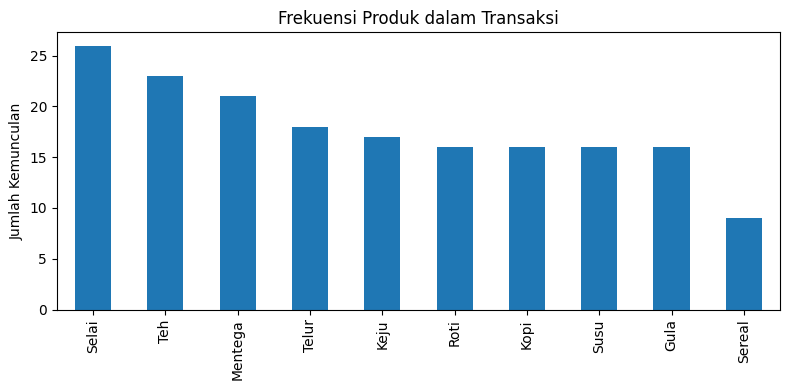

In [1]:
# Suppress warning DeprecationWarning (khusus untuk Google Colab)
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import pandas as pd, numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

produk = ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
          'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega']

# Buat 50 transaksi, tiap transaksi berisi 2-5 produk
transaksi = []
for _ in range(50):
    n_item = np.random.randint(2, 6)
    transaksi.append(list(np.random.choice(produk, n_item, replace=False)))

# Suntikkan pola: Roti sering bersama Selai
for i in range(0, 20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print('Contoh transaksi:', transaksi[:3])
print('Jumlah transaksi:', len(transaksi))

# Eksplorasi frekuensi tiap produk
semua_item = [item for t in transaksi for item in t]
frekuensi = pd.Series(semua_item).value_counts()
print('\nFrekuensi tiap produk:')
print(frekuensi)

frekuensi.plot(kind='bar', figsize=(8, 4), title='Frekuensi Produk dalam Transaksi')
plt.ylabel('Jumlah Kemunculan')
plt.tight_layout()
plt.show()

In [2]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_ary = te.fit(transaksi).transform(transaksi)

df = pd.DataFrame(te_ary, columns=te.columns_)
print(df.head())
print('\nShape:', df.shape)

    Gula   Keju   Kopi  Mentega   Roti  Selai  Sereal   Susu    Teh  Telur
0  False   True   True     True   True   True   False  False  False  False
1  False  False   True     True   True   True   False  False   True  False
2  False  False   True    False  False  False   False   True   True  False
3  False   True  False    False  False   True   False  False   True   True
4   True   True  False     True  False  False   False   True  False  False

Shape: (50, 10)


In [3]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from mlxtend.frequent_patterns import apriori

for ms in [0.05, 0.1, 0.2]:
    freq = apriori(df, min_support=ms, use_colnames=True)
    print(f'min_support={ms}: {len(freq)} itemset ditemukan')

# Gunakan min_support yang menghasilkan jumlah itemset wajar (tidak 0, tidak ratusan)
freq_items = apriori(df, min_support=0.1, use_colnames=True)
freq_items = freq_items.sort_values('support', ascending=False)
print(freq_items.head(10))

min_support=0.05: 74 itemset ditemukan
min_support=0.1: 44 itemset ditemukan
min_support=0.2: 13 itemset ditemukan
    support      itemsets
5      0.52       (Selai)
8      0.46         (Teh)
3      0.42     (Mentega)
9      0.36       (Telur)
1      0.34        (Keju)
0      0.32        (Gula)
2      0.32        (Kopi)
4      0.32        (Roti)
7      0.32        (Susu)
36     0.24  (Selai, Teh)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from mlxtend.frequent_patterns import association_rules

rules = association_rules(freq_items, metric='confidence', min_threshold=0.5)
rules = rules[rules['lift'] > 1].sort_values('lift', ascending=False)

print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

         antecedents consequents  support  confidence      lift
8        (Keju, Teh)     (Telur)     0.12    0.857143  2.380952
14  (Selai, Mentega)      (Kopi)     0.10    0.625000  1.953125
12      (Roti, Gula)     (Selai)     0.10    1.000000  1.923077
7           (Sereal)   (Mentega)     0.14    0.777778  1.851852
10      (Telur, Teh)      (Keju)     0.12    0.600000  1.764706
13     (Selai, Kopi)   (Mentega)     0.10    0.714286  1.700680
9      (Keju, Telur)       (Teh)     0.12    0.750000  1.630435
11     (Selai, Gula)      (Roti)     0.10    0.500000  1.562500
15   (Kopi, Mentega)     (Selai)     0.10    0.714286  1.373626
1             (Roti)     (Selai)     0.22    0.687500  1.322115


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [5]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from sklearn.metrics.pairwise import cosine_similarity

katalog = pd.DataFrame({
    'produk': produk,
    'kategori': ['Bakery', 'Bakery', 'Dairy', 'Bakery', 'Dairy',
                 'Dairy', 'Minuman', 'Bumbu', 'Minuman', 'Dairy']
})

fitur = pd.get_dummies(katalog['kategori'])
sim_matrix = cosine_similarity(fitur)

def rekomendasi_serupa(nama_produk, top_n=3):
    idx = katalog.index[katalog['produk'] == nama_produk][0]
    skor = list(enumerate(sim_matrix[idx]))
    skor = sorted(skor, key=lambda x: x[1], reverse=True)
    skor = [s for s in skor if s[0] != idx][:top_n]
    return katalog.iloc[[i for i, _ in skor]]['produk'].tolist()

print('Mirip dengan Roti:', rekomendasi_serupa('Roti'))

Mirip dengan Roti: ['Selai', 'Sereal', 'Susu']


In [6]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

produk_target = 'Roti'

# Dari association rules: cari consequents dari aturan yang antecedent-nya mengandung produk_target
rules_terkait = rules[rules['antecedents'].apply(lambda x: produk_target in x)]

print('Rekomendasi dari Association Rules:')
print(rules_terkait[['consequents', 'lift']].head())

print('\nRekomendasi dari Content-Based:', rekomendasi_serupa(produk_target))

Rekomendasi dari Association Rules:
   consequents      lift
12     (Selai)  1.923077
1      (Selai)  1.322115

Rekomendasi dari Content-Based: ['Selai', 'Sereal', 'Susu']


## Diskusi: Konsistensi & Kapan Menggunakan Masing-Masing Pendekatan

### Apakah kedua pendekatan konsisten?
Tidak selalu. Untuk contoh `Roti`:
- **Association Rules** merekomendasikan `Selai`, karena pola kemunculan bersama
  di data transaksi (co-occurrence) memang kuat — ini murni berdasarkan *perilaku
  pembelian aktual* pelanggan.
- **Content-Based Filtering** merekomendasikan produk lain dalam kategori yang sama
  (misal `Sereal`, karena sama-sama kategori "Bakery"), tanpa memandang apakah
  produk tersebut pernah dibeli bersamaan atau tidak.

Kedua pendekatan bisa saja tumpang tindih (overlap) kalau kebetulan produk yang
sering dibeli bersama juga berada di kategori yang sama, tapi secara prinsip
keduanya menjawab pertanyaan yang berbeda:
- Association Rules → "Produk apa yang **sering dibeli bersamaan** dengan ini?"
- Content-Based → "Produk apa yang **mirip secara atribut/kategori** dengan ini?"

### Kapan menggunakan masing-masing?

**Gunakan Association Rules (market basket analysis) ketika:**
- Tujuannya adalah *cross-selling* — mendorong pembelian tambahan berdasarkan
  pola transaksi nyata (contoh: bundling promo "beli roti dapat diskon selai").
- Data transaksi historis cukup banyak dan bervariasi, sehingga pola yang
  ditemukan statistik signifikan (bukan kebetulan).
- Tidak masalah jika rekomendasi lintas kategori (misal roti -> selai, bukan
  roti -> roti lain).

**Gunakan Content-Based Filtering ketika:**
- Data transaksi historis sedikit atau tidak tersedia (masalah *cold start*),
  tapi atribut produk (kategori, deskripsi, harga, dsb.) sudah lengkap.
- Tujuannya adalah menawarkan *alternatif/substitusi* produk yang mirip, bukan
  produk pelengkap (misal pelanggan mencari susu, ditawarkan susu merek lain).
- Produk baru diluncurkan dan belum punya cukup riwayat transaksi untuk dianalisis.

**Kapan menggabungkan keduanya (Hybrid)?**
- Untuk sistem rekomendasi e-commerce yang matang, hybrid biasanya paling
  efektif: gunakan Content-Based untuk mengatasi cold start (produk/pelanggan
  baru), lalu perkuat dengan Association Rules begitu data transaksi cukup banyak.
- Hybrid juga berguna untuk *diversifikasi* rekomendasi — menampilkan baik produk
  pelengkap (dari association rules) maupun produk alternatif (dari content-based)
  dalam satu halaman "Rekomendasi untuk Anda", sehingga pelanggan mendapat pilihan
  yang lebih variatif dan relevan.